# Laptop Price Dataset – Data Preprocessing & Analysis

---

## Introduction

This notebook presents a detailed preprocessing and exploratory analysis of a dataset containing information about various **laptop specifications and their prices**. The goal is to prepare the dataset for machine learning tasks by cleaning, transforming, and encoding the features appropriately.

---

## Dataset Description

The dataset contains various features of laptops, including but not limited to:

- **Company**: Brand of the laptop (e.g., Dell, HP, Apple)
- **TypeName**: Type of laptop (e.g., Ultrabook, Gaming, Notebook)
- **Inches**: Screen size
- **ScreenResolution**: Resolution of the screen
- **Cpu**: Processor information
- **Ram**: RAM size
- **Memory**: Storage information
- **Gpu**: Graphics card
- **OpSys**: Operating system
- **Weight**: Weight of the laptop
- **Price**: Target variable (price in local currency or USD)

---

## 🧹 Data Preprocessing Steps

### 1. **Loading the Dataset**

- Read the dataset using `pandas`.
- Display the first few rows to understand the structure.

### 2. **Checking for Missing Values**

- Identify and handle null or missing values.
- Drop or fill rows/columns based on data importance.

### 3. **Feature Cleaning**

- Convert **RAM** and **Weight** columns to numeric types by removing units (e.g., 'GB', 'kg').
- Split compound columns like **ScreenResolution**, **Cpu**, **Memory**, and **Gpu** to extract meaningful components (e.g., SSD, HDD, Flash).

### 4. **Handling Categorical Features**

- Encode all categorical variables using **OneHotEncoding** to prepare for machine learning models.

### 5. **Target Variable**

- Extract and separate the **Price** column as the dependent variable `y`.
- All remaining features are considered independent variables `X`.

---

## 📈 Data Visualization

---

## Next Steps

- Fit regression models like:
  - Linear Regression
  - Polynomial Regression
  - Lasso Regression
  - Ridge Regression
  - Decision Tree
  - Random Forest
- Evaluate model performance using metrics such as:
  - MAE (Mean Absolute Error)
  - MSE (Mean Squared Error)
  - RMSE (Root Mean Squared Error)
  - R2 Score (Coefficient of Determination)

---

## ✅ Conclusion

Through effective preprocessing and cleaning, the laptop dataset is transformed into a structured format suitable for machine learning. This allows for building reliable predictive models to estimate laptop prices based on their technical specifications.


In [114]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso


In [115]:
df = pd.read_csv("laptopData.csv")
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


In [117]:
df.dtypes

Unnamed: 0          float64
Company              object
TypeName             object
Inches               object
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price               float64
dtype: object

In [118]:
df['Unnamed: 0'].tail()


1298    1298.0
1299    1299.0
1300    1300.0
1301    1301.0
1302    1302.0
Name: Unnamed: 0, dtype: float64

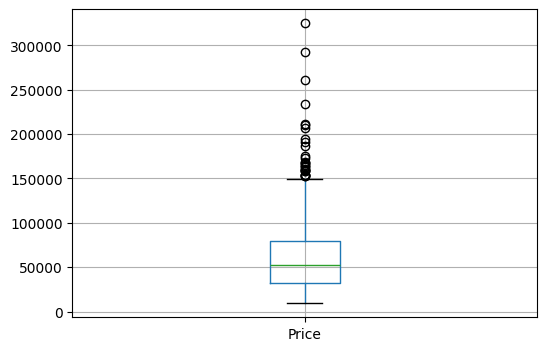

In [119]:
plt.figure(figsize=(6, 4))
df.boxplot(column='Price')
plt.show()

In [120]:
df.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

In [121]:
df.describe()

,Unnamed: 0,Price
count,1273.000000,1273.000000
mean,652.674784,59955.814073
std,376.493027,37332.251005
min,0.000000,9270.720000
25%,327.000000,31914.720000
50%,652.000000,52161.120000
75%,980.000000,79333.387200
max,1302.000000,324954.720000


In [122]:
df.isnull().sum()

Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

In [123]:
df[['Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight']].describe()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
count,1273,1273,1273,1273,1273,1273,1273,1273,1273,1273
unique,19,6,25,40,118,10,40,110,9,189
top,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg
freq,290,710,640,495,183,601,401,271,1047,111


In [124]:
df.drop(columns='Unnamed: 0',inplace=True)

In [125]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [126]:
df[df.isnull().any(axis=1)]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [127]:
df.loc[20,:]

Company             NaN
TypeName            NaN
Inches              NaN
ScreenResolution    NaN
Cpu                 NaN
Ram                 NaN
Memory              NaN
Gpu                 NaN
OpSys               NaN
Weight              NaN
Price               NaN
Name: 20, dtype: object

In [128]:
df.dropna(inplace=True)

In [129]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [130]:
df['TypeName'].unique()

array(['Ultrabook', 'Notebook', 'Gaming', '2 in 1 Convertible',
       'Workstation', 'Netbook'], dtype=object)

In [131]:
df['Company'].unique()

array(['Apple', 'HP', 'Acer', 'Asus', 'Dell', 'Lenovo', 'Chuwi', 'MSI',
       'Microsoft', 'Toshiba', 'Huawei', 'Xiaomi', 'Vero', 'Razer',
       'Mediacom', 'Samsung', 'Google', 'Fujitsu', 'LG'], dtype=object)

In [132]:
df['Inches'].unique()

array(['13.3', '15.6', '15.4', '14', '12', '17.3', '13.5', '12.5', '13',
       '18.4', '13.9', '11.6', '25.6', '35.6', '12.3', '27.3', '24',
       '33.5', '?', '31.6', '17', '15', '14.1', '11.3', '10.1'],
      dtype=object)

In [133]:
df['ScreenResolution'].unique()

array(['IPS Panel Retina Display 2560x1600', '1440x900',
       'Full HD 1920x1080', 'IPS Panel Retina Display 2880x1800',
       '1366x768', 'IPS Panel Full HD 1920x1080',
       'IPS Panel Retina Display 2304x1440',
       'IPS Panel Full HD / Touchscreen 1920x1080',
       'Full HD / Touchscreen 1920x1080',
       'Touchscreen / Quad HD+ 3200x1800', 'Touchscreen 2256x1504',
       'Quad HD+ / Touchscreen 3200x1800', 'IPS Panel 1366x768',
       'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Full HD 2160x1440',
       '4K Ultra HD / Touchscreen 3840x2160', '1600x900',
       'IPS Panel 4K Ultra HD 3840x2160', '4K Ultra HD 3840x2160',
       'Touchscreen 1366x768', 'Touchscreen 2560x1440',
       'IPS Panel Full HD 1366x768', 'IPS Panel 2560x1440',
       'IPS Panel Full HD 2560x1440',
       'IPS Panel Retina Display 2736x1824', 'Touchscreen 2400x1600',
       '2560x1440', 'IPS Panel Quad HD+ 2560x1440',
       'IPS Panel Quad HD+ 3200x1800',
       'IPS Panel Qua

In [134]:
df['Cpu'].unique

<bound method Series.unique of 0                       Intel Core i5 2.3GHz
1                       Intel Core i5 1.8GHz
2                 Intel Core i5 7200U 2.5GHz
3                       Intel Core i7 2.7GHz
4                       Intel Core i5 3.1GHz
                        ...                 
1298              Intel Core i7 6500U 2.5GHz
1299              Intel Core i7 6500U 2.5GHz
1300    Intel Celeron Dual Core N3050 1.6GHz
1301              Intel Core i7 6500U 2.5GHz
1302    Intel Celeron Dual Core N3050 1.6GHz
Name: Cpu, Length: 1273, dtype: object>

In [135]:
df['Ram'].unique()

array(['8GB', '16GB', '4GB', '2GB', '12GB', '64GB', '6GB', '32GB', '24GB',
       '1GB'], dtype=object)

In [136]:
df['Memory'].unique # requires spliting the column into memorySize and memoryType

<bound method Series.unique of 0                 128GB SSD
1       128GB Flash Storage
2                 256GB SSD
3                 512GB SSD
4                 256GB SSD
               ...         
1298              128GB SSD
1299              512GB SSD
1300     64GB Flash Storage
1301                1TB HDD
1302              500GB HDD
Name: Memory, Length: 1273, dtype: object>

In [137]:
df['Gpu'].unique()

array(['Intel Iris Plus Graphics 640', 'Intel HD Graphics 6000',
       'Intel HD Graphics 620', 'AMD Radeon Pro 455',
       'Intel Iris Plus Graphics 650', 'AMD Radeon R5',
       'Intel Iris Pro Graphics', 'Nvidia GeForce MX150',
       'Intel UHD Graphics 620', 'Intel HD Graphics 520',
       'AMD Radeon Pro 555', 'AMD Radeon R5 M430',
       'Intel HD Graphics 615', 'AMD Radeon Pro 560',
       'Nvidia GeForce 940MX', 'Nvidia GeForce GTX 1050', 'AMD Radeon R2',
       'AMD Radeon 530', 'Nvidia GeForce 930MX', 'Intel HD Graphics',
       'Intel HD Graphics 500', 'Nvidia GeForce 930MX ',
       'Nvidia GeForce GTX 1060', 'Nvidia GeForce 150MX',
       'Intel Iris Graphics 540', 'AMD Radeon RX 580',
       'Nvidia GeForce 920MX', 'AMD Radeon R4 Graphics', 'AMD Radeon 520',
       'Nvidia GeForce GTX 1070', 'Nvidia GeForce GTX 1050 Ti',
       'Intel HD Graphics 400', 'Nvidia GeForce MX130', 'AMD R4 Graphics',
       'Nvidia GeForce GTX 940MX', 'AMD Radeon RX 560',
       'Nvidia GeFo

In [138]:
df['OpSys'].unique()

array(['macOS', 'No OS', 'Windows 10', 'Mac OS X', 'Linux',
       'Windows 10 S', 'Chrome OS', 'Windows 7', 'Android'], dtype=object)

In [139]:
df['Weight'].unique()

array(['1.37kg', '1.34kg', '1.86kg', '1.83kg', '2.1kg', '2.04kg', '1.3kg',
       '1.6kg', '2.2kg', '0.92kg', '1.22kg', '2.5kg', '1.62kg', '1.91kg',
       '2.3kg', '1.35kg', '1.88kg', '1.89kg', '1.65kg', '2.71kg', '1.2kg',
       '1.44kg', '2.8kg', '2kg', '2.65kg', '2.77kg', '3.2kg', '1.49kg',
       '2.4kg', '2.13kg', '2.43kg', '1.7kg', '1.4kg', '1.8kg', '1.9kg',
       '3kg', '1.252kg', '2.7kg', '2.02kg', '1.63kg', '1.96kg', '1.21kg',
       '2.45kg', '1.25kg', '1.5kg', '2.62kg', '1.38kg', '1.58kg',
       '1.85kg', '1.23kg', '2.16kg', '2.36kg', '7.2kg', '2.05kg',
       '1.32kg', '1.75kg', '0.97kg', '2.56kg', '1.48kg', '1.74kg',
       '1.1kg', '1.56kg', '2.03kg', '1.05kg', '5.4kg', '4.4kg', '1.90kg',
       '1.29kg', '2.0kg', '1.95kg', '2.06kg', '1.12kg', '3.49kg',
       '3.35kg', '2.23kg', '?', '2.9kg', '4.42kg', '2.69kg', '2.37kg',
       '4.7kg', '3.6kg', '2.08kg', '4.3kg', '1.68kg', '1.41kg', '4.14kg',
       '2.18kg', '2.24kg', '2.67kg', '4.1kg', '2.14kg', '1.36kg',
       '

In [140]:
df[['memorySize', 'memoryType']] = df['Memory'].str.split(' ', n=1, expand=True)

In [141]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,memorySize,memoryType
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,128GB,SSD
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,128GB,Flash Storage
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,256GB,SSD
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,512GB,SSD
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,256GB,SSD


In [142]:
df[df.isnull().any(axis=1)]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,memorySize,memoryType
770,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,16GB,?,AMD Radeon R7 M445,Windows 10,2.3kg,62938.0656,?,None


In [143]:
df[df.isin(['?','-']).any(axis=1)]


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,memorySize,memoryType
208,Dell,Ultrabook,13.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,?,77202.7200,256GB,SSD
476,Dell,Workstation,?,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg,128298.2400,256GB,SSD
770,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,16GB,?,AMD Radeon R7 M445,Windows 10,2.3kg,62938.0656,?,None


In [144]:
f = df[df['TypeName'] == 'Workstation']
f[f['Company'] == 'Dell']

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,memorySize,memoryType
204,Dell,Workstation,15.6,4K Ultra HD 3840x2160,Intel Xeon E3-1505M V6 3GHz,16GB,256GB SSD + 1TB HDD,Nvidia Quadro M1200,Windows 10,2.8kg,162770.4000,256GB,SSD + 1TB HDD
297,Dell,Workstation,17.3,Full HD 1920x1080,Intel Core i7 7820HQ 2.9GHz,16GB,256GB SSD,Nvidia Quadro M1200,Windows 10,3.42kg,153705.3408,256GB,SSD
387,Dell,Workstation,15.6,Full HD 1920x1080,Intel Core i5 6440HQ 2.6GHz,8GB,500GB HDD,AMD FirePro W5130M,Windows 10,2.23kg,72940.3200,500GB,HDD
388,Dell,Workstation,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6820HQ 2.7GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,2kg,113752.8000,256GB,SSD
398,Dell,Workstation,15.6,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg,144495.3600,256GB,SSD
447,Dell,Workstation,15.6,Full HD 1920x1080,Intel Xeon E3-1505M V6 3GHz,8GB,64GB Flash Storage + 1TB HDD,Nvidia Quadro M620,Windows 10,2.23kg,106187.0400,64GB,Flash Storage + 1TB HDD
451,Dell,Workstation,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6820HQ 2.7GHz,16GB,256GB SSD,Nvidia Quadro M620,Windows 10,2.17kg,105228.0000,256GB,SSD
476,Dell,Workstation,?,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg,128298.2400,256GB,SSD
486,Dell,Workstation,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6820HQ 2.7GHz,16GB,512GB SSD,Nvidia Quadro M620,Windows 10,2.17kg,124568.6400,512GB,SSD
599,Dell,Workstation,15.6,Full HD / Touchscreen 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M620,Windows 10,2.06kg,93932.6400,256GB,SSD


In [145]:
rows_to_drop = df[df.isin(['?', '-']).any(axis=1)].index
df = df.drop(rows_to_drop)

In [146]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

In [150]:
# Step 1: Separate features and target
y = df['Price']
X = df.drop('Price', axis=1)

# Step 2: One-hot encode all columns in X
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_enc = encoder.fit_transform(X)

# Step 3: Get correct new column names
encoded_col_names = encoder.get_feature_names_out(X.columns)

# Step 4: Create the new encoded DataFrame
X_encoded = pd.DataFrame(X_enc, columns=encoded_col_names, index=X.index)

# Done
X_encoded

,Company_Acer,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,Company_HP,Company_Huawei,Company_LG,...,memoryType_HDD,memoryType_HDD + 1TB HDD,memoryType_Hybrid,memoryType_SSD,memoryType_SSD + 1.0TB Hybrid,memoryType_SSD + 1TB HDD,memoryType_SSD + 256GB SSD,memoryType_SSD + 2TB HDD,memoryType_SSD + 500GB HDD,memoryType_SSD + 512GB SSD
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1299,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1301,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [152]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [156]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Linear Regression Results ---")
print(f"Coefficients (slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")



--- Linear Regression Results ---
Coefficients (slope): -7781.67
Intercept: 77348.26
Mean Absolute Error (MAE): 8855.33
Mean Squared Error (MSE): 233287183.72
Root Mean Squared Error (RMSE): 15273.74
R-squared (R2): 0.79


In [157]:
#Transform features to polynomial features (degree 2)
poly_features = PolynomialFeatures(degree=2)

X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("\n--- Polynomial Regression Results (Degree 2) ---")
print(f"Mean Absolute Error (MAE): {mae_poly:.2f}")
print(f"Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_poly:.2f}")

print(f"R-squared (R2): {r2_poly:.2f}")


--- Polynomial Regression Results (Degree 2) ---
Mean Absolute Error (MAE): 8616.58
Mean Squared Error (MSE): 171303475.79
Root Mean Squared Error (RMSE): 13088.30
R-squared (R2): 0.85


In [170]:
lasso = Lasso(alpha=10, max_iter=1000)  # alpha controls regularization strength
lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Lasso Regression Results ---")
print(f"Coefficients: {lasso.coef_}")
print(f"Intercept: {lasso.intercept_:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


--- Lasso Regression Results ---
Coefficients: [-5.36184149e+03 -0.00000000e+00 -2.95365431e+03 -0.00000000e+00
  0.00000000e+00 -0.00000000e+00  5.44568661e+02 -4.43732437e+02
 -1.03508277e+04  1.58274319e+04 -2.39928188e+03  3.74324364e+03
 -7.27302819e+03  0.00000000e+00  1.95657534e+04  8.51687574e+03
  4.28586045e+03 -5.41038944e+03  9.36045483e+02  0.00000000e+00
 -6.49306159e+03 -0.00000000e+00 -4.34512605e+03  2.03991952e+03
  2.81484585e+04  0.00000000e+00  0.00000000e+00 -4.44878361e+03
  0.00000000e+00  0.00000000e+00  1.10243331e+04 -1.96869221e+03
 -3.68752589e+03  5.90291112e+03  2.66787140e+03  0.00000000e+00
  0.00000000e+00  0.00000000e+00  4.39622854e+04 -9.87476923e+03
 -0.00000000e+00  1.79992004e+03  2.71760057e+04  0.00000000e+00
  0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -7.08661006e+03 -6.58037125e+03 -6.63629102e+02 -1.18491319e+04
 -0.00000000e+00  2.40525236e+04  2.87339165e+04  1.64491104e+03
 -2.65062645e+03 -2.66784154e+03 -1.303880

In [165]:
ridge = Ridge(alpha=1.0)  # alpha controls the strength of L2 regularization
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Ridge Regression Results ---")
print(f"Coefficients: {ridge.coef_}")
print(f"Intercept: {ridge.intercept_:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


--- Ridge Regression Results ---
Coefficients: [-7.76053703e+03 -1.59140618e+03 -5.68930523e+03 -1.52023052e+03
 -8.91130449e+02 -4.60977561e+03  2.01868097e+03 -2.13793636e+03
 -6.30020779e+03  1.52040698e+04 -4.02764313e+03  2.92878323e+03
 -1.03739798e+04  4.24616539e+03  1.58255117e+04  6.74918422e+03
  3.79707038e+03 -8.69950363e+03  2.83219009e+03 -1.96987393e+03
 -8.88091282e+03 -2.94095433e+03 -9.88836469e+03 -2.44355377e+03
  2.61236595e+04 -1.39492955e+03  0.00000000e+00 -5.16470075e+03
 -1.91757247e+03 -2.73008495e+03  8.88747929e+03 -6.30020779e+03
 -1.87868200e+03  4.71245737e+03  6.39416188e+03  2.64113187e+03
  0.00000000e+00 -1.97360037e+03  1.39209800e+04 -6.92334986e+03
 -7.52938573e+02  5.47797871e+03  7.84185722e+03 -9.76186294e+02
  0.00000000e+00 -7.33797468e+03 -4.46459811e+03 -4.66291977e+02
 -7.59492901e+03 -8.83276327e+03 -5.67308520e+03 -1.54631284e+04
 -3.49685620e+03  1.10329511e+04  2.58910247e+04  2.21783177e+03
 -6.22066987e+03 -5.15011434e+03 -3.546234

In [182]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Decision Tree Regressor Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


--- Decision Tree Regressor Results ---
Mean Absolute Error (MAE): 10101.04
Mean Squared Error (MSE): 263682270.25
Root Mean Squared Error (RMSE): 16238.30
R-squared (R2): 0.76


In [179]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Random Forest Regressor Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


--- Random Forest Regressor Results ---
Mean Absolute Error (MAE): 8890.83
Mean Squared Error (MSE): 236887924.09
Root Mean Squared Error (RMSE): 15391.16
R-squared (R2): 0.79
